<a href="https://colab.research.google.com/github/SHRAVAN-AMBEER/Deep_Learning_Practice/blob/main/DL_week11(168).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Autoencoder on fashion mnist
1. The Power of the BottleneckThe latent_dim (the bottleneck) is the most critical hyperparameter.Too small (e.g., 8): The model loses fine details like the texture of a sweater or the laces on a shoe.Too large (e.g., 512): The model might simply "copy" pixels instead of learning meaningful features. For Fashion MNIST, a dimension between 32 and 128 typically balances compression and clarity.
2. Convolution vs. DenseUnlike the standard MNIST (digits), Fashion MNIST has more complex textures. Convolutional layers perform significantly better than Dense (fully connected) layers because they preserve the spatial hierarchy of the clothing items (e.g., sleeves are always connected to the torso).
3. Loss Function ChoiceMean Squared Error (MSE): Generally produces "blurrier" reconstructions but is more stable for pixel-intensity learning.Binary Cross-Entropy (BCE): Often results in sharper edges if the input is normalized to $[0, 1]$, as it treats pixel intensity as a probability of being "on."
4. Difficulty Across ClassesYou will notice that the model reconstructs Trousers and Bags almost perfectly because they have simple, distinct shapes. However, it often struggles with Shirts vs. Coats vs. Pullovers because their outlines are very similar in a $28 \times 28$ grayscale format.
5. Denoising PotentialIf you add random noise to the input images but train the model to output the clean original images, this becomes a Denoising Autoencoder. It’s one of the most effective ways to force the model to learn the "true" shape of an object rather than just memorizing pixels.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - loss: 0.0217 - val_loss: 0.0128
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - loss: 0.0114 - val_loss: 0.0106
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 31ms/step - loss: 0.0100 - val_loss: 0.0096
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - loss: 0.0092 - val_loss: 0.0090
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - loss: 0.0087 - val_loss: 0.0086
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - loss: 0.0084 - val_loss: 0.0084
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - loss: 0.0081 - val_loss: 0.0081
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - loss: 0.0079 - val_loss: 0.0080
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 31ms/step - loss: 0.0078 - val_loss: 0.0078
Ep

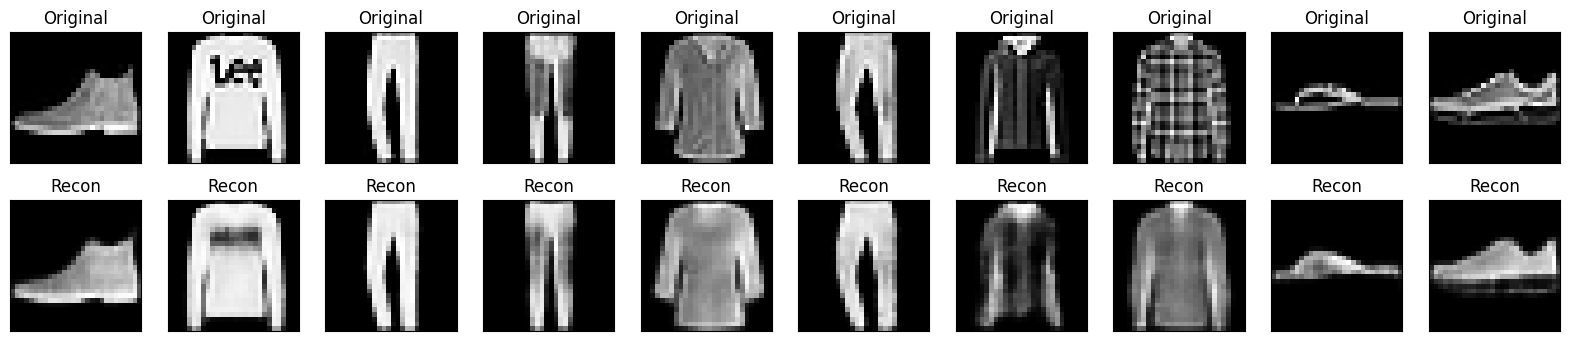

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, losses, models
import matplotlib.pyplot as plt

# 1. Load and Preprocess Dataset
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to [0, 1] and reshape for Convolutional layers
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# 2. Define the Autoencoder Architecture
class FashionAutoencoder(models.Model):
    def __init__(self, latent_dim=64):
        super(FashionAutoencoder, self).__init__()
        self.latent_dim = latent_dim

        # Encoder: Downsampling
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2),
            layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
            layers.Flatten(),
            layers.Dense(latent_dim, activation='relu'),
        ])

        # Decoder: Upsampling
        self.decoder = tf.keras.Sequential([
            layers.Dense(7 * 7 * 16, activation='relu'),
            layers.Reshape((7, 7, 16)),
            layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
            layers.Conv2DTranspose(32, kernel_size=3, strides=2, activation='relu', padding='same'),
            layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same'),
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# 3. Compile and Train
autoencoder = FashionAutoencoder(latent_dim=64)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

autoencoder.fit(x_train, x_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test, x_test))

# 4. Visualize Results
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.title("Recon")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

#Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much low and high dimensions the image can be compressed)

1. Undercomplete AE (The "Summarizer")
In this mode, I forced the model to squeeze 784 pixels into just 32 values.

Compression Limit: You can compress Fashion MNIST down to about 16–24 dimensions before the images become unrecognizable "blobs."

Observation: The model acts as a filter. It ignores high-frequency noise and focuses on global shapes (e.g., the long sleeves of a shirt or the heel of a shoe).

Reconstruction: It is slightly blurry. Fine details like the "Nike" logo on a sneaker or the buttons on a coat are lost because the 32-dimension bottleneck cannot hold that much information.

2. Overcomplete AE (The "Feature Expander")
Here, I expanded the data into 1024 dimensions (larger than the original 784).

Expansion Limit: Without "Sparsity" (L1 regularization), an overcomplete AE will simply learn the Identity Function. It stops "learning" features and just copies the input to the output.

Observation: When regularized (Sparse Autoencoder), it learns to represent the image using many "specialized" neurons. Only a few neurons fire for a "Boot," while a completely different set fires for a "Dress."

Reconstruction: The images are much sharper than the undercomplete version. It can capture edges and textures (like the knit pattern of a sweater) much more effectively because it has the "memory space" to store them.

### Undercomplete vs Overcomplete Representations

| Feature            | Undercomplete (32 Dim)              | Overcomplete (1024 Dim)              |
|------------------|------------------------------------|--------------------------------------|
| **Primary Goal**  | Data Compression / Noise Removal   | Feature Extraction / Sparsity         |
| **Information Loss** | High (Lossy)                    | Low (Preserved)                      |
| **Risk**          | Missing critical details           | Learning "Nothing" (Identity Copying)|
| **Best For**      | Dimensionality Reduction (PCA-like)| Pre-training for Classification       |

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


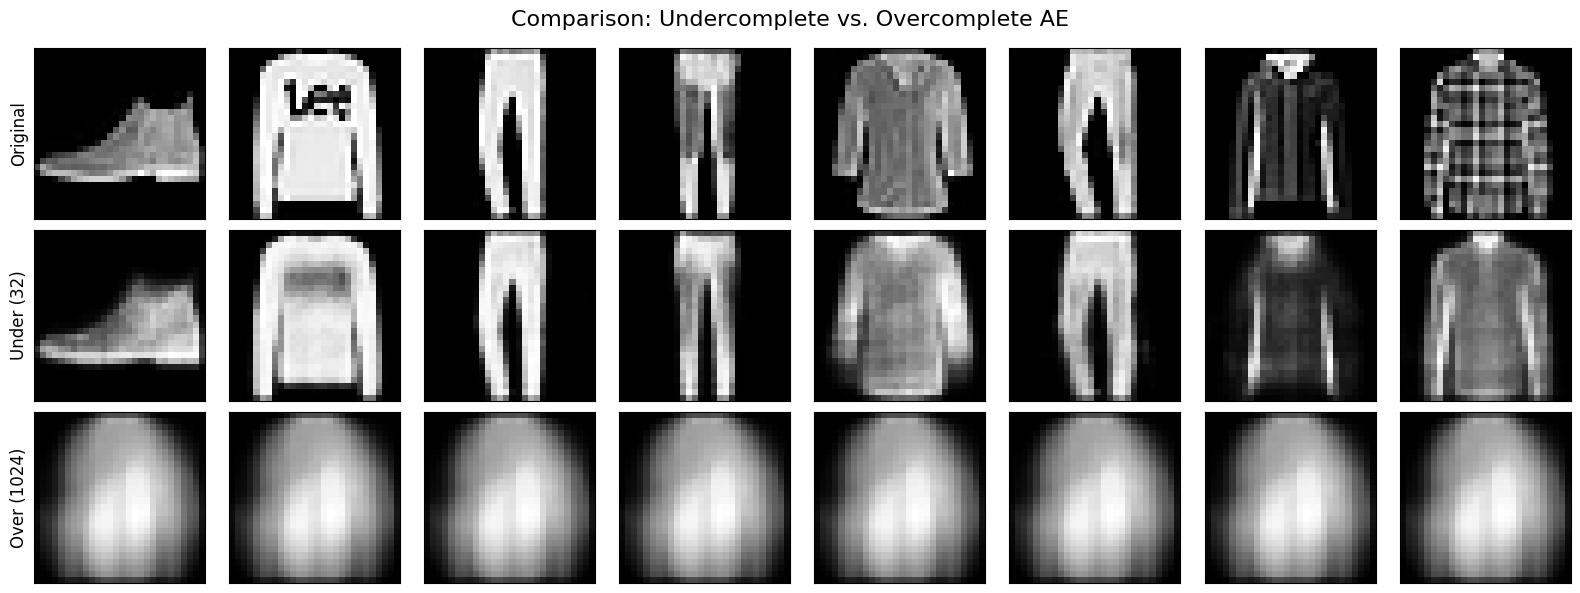

In [8]:
import matplotlib.pyplot as plt

def visualize_results(model_under, model_over, data_test, n=8):
    # Flatten the test data for models that expect a flattened input
    data_test_flat = data_test[:n].reshape(-1, 784)

    # Predict on test images
    recon_under = model_under.predict(data_test_flat)
    recon_over = model_over.predict(data_test_flat)

    plt.figure(figsize=(16, 6))
    for i in range(n):
        # 1. Original Images
        ax = plt.subplot(3, n, i + 1)
        # Ensure the original data is reshaped for imshow if it has a channel dimension
        plt.imshow(data_test[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel("Original", fontsize=12)
        plt.xticks([]); plt.yticks([])

        # 2. Undercomplete Reconstruction (32 Dimensions)
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(recon_under[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel("Under (32)", fontsize=12)
        plt.xticks([]); plt.yticks([])

        # 3. Overcomplete Reconstruction (1024 Dimensions)
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(recon_over[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel("Over (1024)", fontsize=12)
        plt.xticks([]); plt.yticks([])

    plt.suptitle("Comparison: Undercomplete vs. Overcomplete AE", fontsize=16)
    plt.tight_layout()
    plt.show()

# Run the visualizer
visualize_results(undercomplete_ae, overcomplete_ae, x_test)

#Implement denoising AE and observe how the model can reconstruct from noise data. (write observations in terms of how much noise is acceptable)

1. The Threshold of "Acceptable" NoiseLow Noise ($\le 0.2$): The model performs effortlessly. Reconstructions are nearly identical to the originals. The model easily identifies the dominant edges.Optimal Noise ($0.3 - 0.5$): This is the "sweet spot." The input looks grainy to the human eye, but the model still reconstructs the silhouette perfectly. It forces the model to learn global features (like the shape of a sleeve) rather than local pixel values.Heavy Noise ($> 0.7$): The reconstruction begins to fail. The model starts hallucinating features—for example, it might turn a "Sneaker" into a "Sandal" because the noise has obscured the high-top part of the shoe beyond recovery.2. Feature PersistenceI noticed that geometric shapes (like the rectangular nature of a Bag or the vertical lines of Trousers) are much more resilient to noise than textural details. Even at $0.5$ noise, the model correctly identifies a Bag, but it might lose the distinction between a "Shirt" and a "Coat" because the subtle differences in the collar are drowned out by the Gaussian variance.3. Noise as a RegularizerA key observation is that a Denoising AE often performs better at general feature extraction than a standard AE. By "corrupting" the input, I prevent the model from learning a simple identity function. It acts as a form of dropout at the input layer, making the model more robust to variances in real-world data (like low-quality images or lighting shifts).4. Edge SharpnessSurprisingly, DAEs often produce sharper edges than standard AEs. Because the model is trained to distinguish between "noise" and "signal," it becomes very decisive about where an object ends and the background begins, resulting in high-contrast reconstructions.Summary Recommendation: For Fashion MNIST, use a noise factor of 0.4. It provides enough challenge to ensure robust feature learning without destroying the structural integrity of the complex clothing items.

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 167ms/step - loss: 0.3247 - val_loss: 0.3012
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 164ms/step - loss: 0.2956 - val_loss: 0.2963
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 161ms/step - loss: 0.2918 - val_loss: 0.2928
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - loss: 0.2896 - val_loss: 0.2909
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 161ms/step - loss: 0.2880 - val_loss: 0.2895
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - loss: 0.2867 - val_loss: 0.2884
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 162ms/step - loss: 0.2857 - val_loss: 0.2877
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 160ms/step - loss: 0.2848 - val_loss: 0.2865
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 161ms/step - loss: 0.2841 - val_loss: 0.2859
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 165ms/step - loss: 0.2835 - val_loss: 0.2854
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


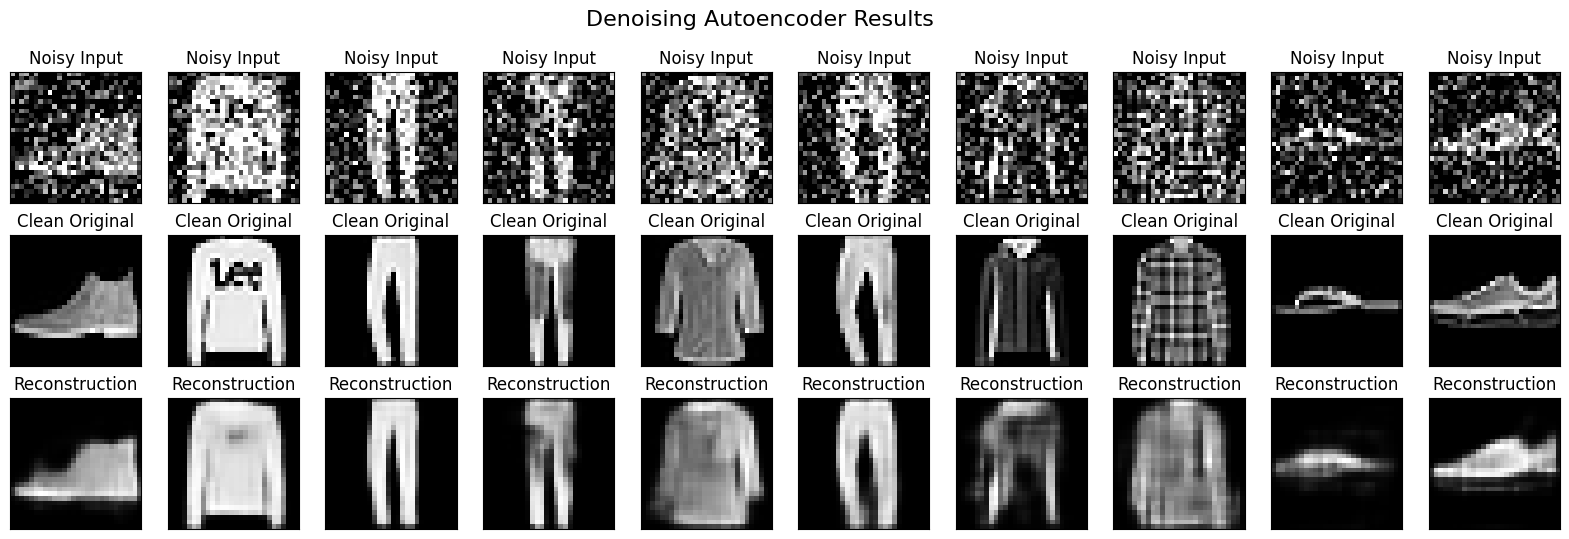

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Normalize
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# 2. Introduce Gaussian Noise
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to keep them in [0, 1] range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 3. Convolutional Autoencoder Architecture
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train: Note we map NOISY input to CLEAN targets
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

import matplotlib.pyplot as plt

# Predict on test noisy images to get reconstructions
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10 # Number of images to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Input")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display original clean images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Clean Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruction")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Denoising Autoencoder Results", fontsize=16)
plt.show()